In [1]:
import torch
t_version = str(torch.__version__)
s_src = f"https://pytorch-geometric.com/whl/torch-{t_version}.html"
sp_src = f"https://pytorch-geometric.com/whl/torch-{t_version}.html"
!pip install torch-scatter -f $s_src
!pip install torch-sparse -f $sp_src
!pip install torch-geometric
!pip install -q git+https://github.com/snap-stanford/deepsnap.git

Looking in links: https://pytorch-geometric.com/whl/torch-2.2.2+cpu.html
Looking in links: https://pytorch-geometric.com/whl/torch-2.2.2+cpu.html


  ERROR: Error [WinError 2] The system cannot find the file specified while executing command git clone -q https://github.com/snap-stanford/deepsnap.git 'C:\Users\SRMAPCSELAB2022-346\AppData\Local\Temp\pip-req-build-otd1secg'
ERROR: Cannot find command 'git' - do you have 'git' installed and in your PATH?


In [2]:
import torch_geometric
torch_geometric.__version__

'2.6.1'

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing
from tqdm import trange
from torch_geometric.utils import add_self_loops, softmax
from sklearn.metrics import roc_auc_score, average_precision_score
from torch_scatter import scatter
from torch_geometric.utils import degree  


class GraphNNStack(nn.Module):
    def __init__(self, input_features, hidden_features, output_features, configuration,return_embeddings=True):
        super(GraphNNStack, self).__init__()

        conv_layer_class = self.select_conv_layer(configuration.model_type)

        self.conv_layers = nn.ModuleList()

        # Input layer
        self.conv_layers.append(
            conv_layer_class(input_features, hidden_features, dropout=configuration.dropout)
        )

        # Hidden layers
        for _ in range(configuration.num_layers - 2):
            self.conv_layers.append(
                conv_layer_class(hidden_features, hidden_features, dropout=configuration.dropout)
            )

        # Output layer
        self.conv_layers.append(
            conv_layer_class(hidden_features, output_features, dropout=configuration.dropout)
        )

    def select_conv_layer(self, conv_type):
        if conv_type == 'MGCN':
            return MGCN
        else:
            raise ValueError(f"Unknown model type: {conv_type}")

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        for conv in self.conv_layers:
            x = conv(x, edge_index)

        return x

    def decode(self, z, edge_label_index):
        return (z[edge_label_index[0]] * z[edge_label_index[1]]).sum(dim=-1)

In [4]:
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import add_self_loops, degree, softmax
from torch.nn import Parameter


# Define MGCN model
class MGCN(MessagePassing):
    def __init__(self,in_channels, out_channels,dropout=0.5,
                 negative_slope=0.2,residual=True,heads=1, attention=False):
        super(MGCN, self).__init__(aggr='add')
        self.negative_slope = negative_slope

        if attention and out_channels % heads != 0:
            raise ValueError(f"out_channels ({out_channels}) must be divisible by heads ({heads})")

        self.lin = nn.Linear(in_channels, out_channels, bias=True)
        self.dropout = dropout
        self.residual = residual
        self.attention = attention

        if residual:
            self.res_lin = nn.Linear(in_channels, out_channels) if in_channels != out_channels else nn.Identity()

        if attention:
            self.heads = heads
            self.out_channels = out_channels // heads
            self.att_lin = nn.Linear(2 * self.out_channels, 1)

        self.reset_parameters()

    def reset_parameters(self):
        self.lin.reset_parameters()
        if hasattr(self, 'res_lin') and not isinstance(self.res_lin, nn.Identity):
            self.res_lin.reset_parameters()
        if hasattr(self, 'att_lin'):
            self.att_lin.reset_parameters()
    def forward(self, x, edge_index,edge_weight=None):
        res = x if self.residual else None

        edge_index, _ = add_self_loops(edge_index, num_nodes=x.size(0))
        row, col = edge_index

        deg = degree(row, x.size(0), dtype=x.dtype)
        deg_inv_sqrt = (deg + 1e-5).pow(-0.5).clamp(max=1e4)
        norm = deg_inv_sqrt[row] * deg_inv_sqrt[col]

        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.lin(x)

        if edge_weight is not None:
            num_self_loops = x.size(0)
            edge_weight = torch.cat([edge_weight, torch.ones(num_self_loops, device=edge_index.device)])
            norm = norm * edge_weight

        if self.attention:
            x = x.view(-1, self.heads, self.out_channels)
            out = self.propagate(edge_index, x=x, norm=norm)

            out = out.view(-1, self.heads * self.out_channels)

            if self.residual:
                out = F.relu(out) + self.res_lin(res)
            else:
                out = F.relu(out)
            return out
        else:
            out = self.propagate(edge_index, x=x, norm=norm)
            if self.residual:
                out = out + self.res_lin(res)
            return F.relu(out)
            

    def message(self, x_j, x_i, norm, index):
        if self.attention:
            x_j = x_j.view(-1, self.heads, self.out_channels)
            x_i = x_i.view(-1, self.heads, self.out_channels)
            alpha = torch.cat([x_i, x_j], dim=-1)
            alpha = F.leaky_relu(self.att_lin(alpha).squeeze(-1),negative_slope=self.negative_slope)
            alpha = softmax(alpha / np.sqrt(self.out_channels), index)  # Scale by sqrt(d_k)
            return (alpha.unsqueeze(-1) * x_j).view(-1, self.heads * self.out_channels)
        else:
            return norm.view(-1, 1) * x_j

In [5]:
import torch.optim as optim
def setup_optimizer_and_scheduler(configuration, model_params):
    weight_decay = configuration.weight_decay
    trainable_params = filter(lambda p: p.requires_grad, model_params)

    if configuration.optimizer == 'adam':
        optimizer = torch.optim.Adam(trainable_params, lr=configuration.learning_rate, weight_decay=weight_decay)
    elif configuration.optimizer == 'sgd':
        optimizer = torch.optim.SGD(trainable_params, lr=configuration.learning_rate, momentum=0.95, weight_decay=weight_decay)
    else:
        optimizer = torch.optim.Adam(trainable_params, lr=configuration.learning_rate, weight_decay=weight_decay)

    return None, optimizer

In [6]:
import torch.optim as optim
import time
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from torch_geometric.data import HeteroData, Data
import requests
import zipfile
import io
import torch.nn.functional as F
from torch_geometric.utils import negative_sampling
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score, f1_score


def download_and_extract_movielens():
    """Download MovieLens 1M dataset and extract it"""
    print("Downloading MovieLens 1M dataset...")
    
    url = "http://files.grouplens.org/datasets/movielens/ml-1m.zip"
    response = requests.get(url)

    if response.status_code != 200:
        raise Exception(f"Failed to download dataset: HTTP {response.status_code}")

    # Create extraction directory
    extract_path = 'movielens'
    if not os.path.exists(extract_path):
        os.makedirs(extract_path)
    
    # Extract zip
    with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
        zip_ref.extractall(extract_path)

    print("Dataset downloaded and extracted successfully!")
    
    # Expected folder structure
    extracted_folder = os.path.join(extract_path, 'ml-1m')
    
    if os.path.exists(extracted_folder):
        print(f"Files extracted to: {extracted_folder}")
        return extracted_folder
    else:
        # Debug: print directory structure (same as LastFM style)
        print("Contents of extraction directory:")
        for root, dirs, files in os.walk(extract_path):
            level = root.replace(extract_path, '').count(os.sep)
            indent = ' ' * 2 * level
            print(f"{indent}{os.path.basename(root)}/")
            subindent = ' ' * 2 * (level + 1)
            for file in files[:5]:  # show first 5 files
                print(f"{subindent}{file}")
        
        return extract_path


def load_movielens_heterogeneous(data_path, embedding_dim=128):
    """Load MovieLens dataset and create HeteroData object with learnable embeddings"""
    
    print(f"Loading MovieLens dataset from: {data_path}")
    
    # Debug: list files
    print("\nAvailable files in directory:")
    try:
        for f in os.listdir(data_path):
            print(f"  - {f}")
    except:
        print("  Could not list directory contents")
    
    # ============================
    # Load files (with checks)
    # ============================
    try:
        users_df = pd.read_csv(
            os.path.join(data_path, 'users.dat'),
            sep='::', engine='python',
            names=['UserID','Gender','Age','Occupation','Zip'],
            encoding='latin-1'
        )
        print(f"✓ Loaded users.dat: {len(users_df)} records")
    except:
        print("✗ users.dat not found")
        raise

    try:
        movies_df = pd.read_csv(
            os.path.join(data_path, 'movies.dat'),
            sep='::', engine='python',
            names=['MovieID','Title','Genres'],
            encoding='latin-1'
        )
        print(f"✓ Loaded movies.dat: {len(movies_df)} records")
    except:
        print("✗ movies.dat not found")
        raise

    try:
        ratings_df = pd.read_csv(
            os.path.join(data_path, 'ratings.dat'),
            sep='::', engine='python',
            names=['UserID','MovieID','Rating','Timestamp']
        )
        print(f"✓ Loaded ratings.dat: {len(ratings_df)} records")
    except:
        print("✗ ratings.dat not found")
        raise

    # ============================
    # Create HeteroData
    # ============================
    data = HeteroData()

    # Unique users & movies
    all_users = set(users_df['UserID']).union(set(ratings_df['UserID']))
    all_movies = set(movies_df['MovieID']).union(set(ratings_df['MovieID']))

    num_users = len(all_users)
    num_movies = len(all_movies)

    user_id_to_idx = {uid: i for i, uid in enumerate(sorted(all_users))}
    movie_id_to_idx = {mid: i for i, mid in enumerate(sorted(all_movies))}

    print(f"\nStatistics - Users: {num_users}, Movies: {num_movies}")

    # ============================
    # ✅ Learnable embeddings (same idea as LastFM)
    # ============================
    print(f"\nUsing learnable embeddings with dimension: {embedding_dim}")

    user_embeddings = nn.Parameter(torch.randn(num_users, embedding_dim))
    movie_embeddings = nn.Parameter(torch.randn(num_movies, embedding_dim))

    nn.init.xavier_uniform_(user_embeddings)
    nn.init.xavier_uniform_(movie_embeddings)

    # Normalize (same as your LastFM code)
    user_embeddings = nn.Parameter(F.normalize(user_embeddings, p=2, dim=1))
    movie_embeddings = nn.Parameter(F.normalize(movie_embeddings, p=2, dim=1))

    data['user'].x = user_embeddings
    data['movie'].x = movie_embeddings

    data['user'].num_nodes = num_users
    data['movie'].num_nodes = num_movies

    # ============================
    # Edges: User → Movie (ratings)
    # ============================
    edge_index = []
    edge_weight = []

    valid_edges = 0
    skipped_edges = 0

    for _, row in ratings_df.iterrows():
        u = row['UserID']
        m = row['MovieID']

        if u in user_id_to_idx and m in movie_id_to_idx:
            edge_index.append([user_id_to_idx[u], movie_id_to_idx[m]])
            edge_weight.append(float(row['Rating']))
            valid_edges += 1
        else:
            skipped_edges += 1

    print(f"User-rates-movie relations: {valid_edges}")

    if edge_index:
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        edge_weight = torch.tensor(edge_weight, dtype=torch.float)

        data['user', 'rates', 'movie'].edge_index = edge_index
        data['user', 'rates', 'movie'].weight = edge_weight

        # IMPORTANT: store original edges (same as LastFM)
        data['user', 'rates', 'movie'].original_edge_index = edge_index.clone()

    # ============================
    # FINAL STATS
    # ============================
    print(f"\nFINAL STATISTICS:")
    print(f"  Users: {data['user'].num_nodes}")
    print(f"  Movies: {data['movie'].num_nodes}")
    print(f"  User→Movie edges: {valid_edges}")
    print(f"  Embedding dimension: {embedding_dim}")

    return data

def convert_movielens_to_homogeneous(data):
    """Convert MovieLens heterogeneous graph to homogeneous graph (LastFM-style)"""
    print("Converting to homogeneous graph...")

    num_users = data['user'].num_nodes
    num_movies = data['movie'].num_nodes
    total_nodes = num_users + num_movies

    edge_indices = []

    # =========================================================
    # User-rates-movie edges (bidirectional)
    # =========================================================
    if ('user', 'rates', 'movie') in data.edge_types:

        user_rates_movie = data['user', 'rates', 'movie'].edge_index

        # user → movie
        user_rates_movie_adj = user_rates_movie.clone()
        user_rates_movie_adj[1] += num_users

        # movie → user
        movie_rates_user = torch.stack(
            [user_rates_movie[1], user_rates_movie[0]], dim=0
        )
        movie_rates_user[0] += num_users  # shift movie nodes
        movie_rates_user[1] += 0          # users stay same

        edge_indices.append(user_rates_movie_adj)
        edge_indices.append(movie_rates_user)

    # =========================================================
    # Combine edges
    # =========================================================
    if edge_indices:
        edge_index = torch.cat(edge_indices, dim=1)
        edge_index = torch.unique(edge_index, dim=1)
        print(f"Created {edge_index.shape[1]} edges in homogeneous graph")
    else:
        edge_index = torch.empty((2, 0), dtype=torch.long)
        print("Warning: No edges found!")

    # =========================================================
    # Combine node features (same as LastFM style)
    # =========================================================
    user_features = data['user'].x.float()
    movie_features = data['movie'].x.float()

    max_dim = max(user_features.shape[1], movie_features.shape[1])

    if user_features.shape[1] < max_dim:
        user_features = F.pad(user_features, (0, max_dim - user_features.shape[1]))

    if movie_features.shape[1] < max_dim:
        movie_features = F.pad(movie_features, (0, max_dim - movie_features.shape[1]))

    x = torch.cat([user_features, movie_features], dim=0)

    # =========================================================
    # Store original edges (for link prediction)
    # =========================================================
    original_edges = None
    if ('user', 'rates', 'movie') in data.edge_types:
        original_edges = data['user', 'rates', 'movie'].edge_index
        print(f"Stored original user-movie edges: {original_edges.shape[1]}")

    # =========================================================
    # Create homogeneous Data object
    # =========================================================
    homogeneous_data = Data(
        x=x,
        edge_index=edge_index,
        num_nodes=total_nodes,
        num_users=num_users,
        num_movies=num_movies,
        original_user_movie_edges=original_edges
    )

    print(f"Homogeneous graph created with {homogeneous_data.num_nodes} nodes")
    return homogeneous_data


def print_dataset_details(homogeneous_data):
    """Print dataset details for MovieLens 1M"""
    print("\n" + "="*60)
    print(f"Dataset name: MovieLens 1M")

    print(f"Total nodes: {homogeneous_data.num_nodes}")
    print(f"Total edges: {homogeneous_data.edge_index.shape[1]}")

    print(f"Number of user nodes: {homogeneous_data.num_users}")
    print(f"Number of movie nodes: {homogeneous_data.num_movies}")

    print(f"Feature dimension: {homogeneous_data.x.shape[1]}")
    print("="*60)

    
    
def prepare_link_prediction_data(homogeneous_data):
    """Prepare homogeneous graph data for link prediction using real user-movie interactions"""
    print("\n" + "="*60)
    print("Preparing data for link prediction...")
    print("="*60)

    num_users = homogeneous_data.num_users
    num_movies = homogeneous_data.num_movies

    # =========================================================
    # Check original edges
    # =========================================================
    if not hasattr(homogeneous_data, "original_user_movie_edges") or homogeneous_data.original_user_movie_edges is None:
        print("ERROR: No original user-movie edges found!")
        return homogeneous_data

    # =========================================================
    # Positive edges (user-movie)
    # movie nodes are shifted by num_users in homogeneous graph
    # =========================================================
    pos_edge_index = homogeneous_data.original_user_movie_edges.clone()
    pos_edge_index[1] += num_users

    print(f"Original user-movie edges: {pos_edge_index.shape[1]}")

    pos_edge_label = torch.ones(pos_edge_index.size(1), dtype=torch.float)

    # =========================================================
    # Negative sampling
    # =========================================================
    num_neg_samples = pos_edge_index.size(1) * 3

    neg_users = torch.randint(0, num_users, (num_neg_samples,))
    neg_movies = torch.randint(num_users, num_users + num_movies, (num_neg_samples,))

    neg_edge_index = torch.stack([neg_users, neg_movies])
    neg_edge_label = torch.zeros(neg_edge_index.size(1), dtype=torch.float)

    # =========================================================
    # Combine positive + negative
    # =========================================================
    all_edge_index = torch.cat([pos_edge_index, neg_edge_index], dim=1)
    all_edge_label = torch.cat([pos_edge_label, neg_edge_label])

    # Shuffle
    perm = torch.randperm(all_edge_index.size(1))
    all_edge_index = all_edge_index[:, perm]
    all_edge_label = all_edge_label[perm]

    # =========================================================
    # Train / Val / Test split (70/15/15)
    # =========================================================
    num_edges = all_edge_index.size(1)
    train_size = int(0.7 * num_edges)
    val_size = int(0.15 * num_edges)

    train_edge_index = all_edge_index[:, :train_size]
    train_edge_label = all_edge_label[:train_size]

    val_edge_index = all_edge_index[:, train_size:train_size + val_size]
    val_edge_label = all_edge_label[train_size:train_size + val_size]

    test_edge_index = all_edge_index[:, train_size + val_size:]
    test_edge_label = all_edge_label[train_size + val_size:]

    # =========================================================
    # Store in data object
    # =========================================================
    homogeneous_data.train_pos_edge_index = train_edge_index[:, train_edge_label == 1]
    homogeneous_data.train_edge_index = train_edge_index
    homogeneous_data.train_edge_label = train_edge_label

    homogeneous_data.val_edge_index = val_edge_index
    homogeneous_data.val_edge_label = val_edge_label

    homogeneous_data.test_edge_index = test_edge_index
    homogeneous_data.test_edge_label = test_edge_label

    # =========================================================
    # Print statistics
    # =========================================================
    print(f"\nLink Prediction Data Statistics:")
    print(f"Total edges: {num_edges} ({pos_edge_index.shape[1]} positive, {neg_edge_index.shape[1]} negative)")
    print(f"Train edges: {train_edge_index.shape[1]} ({int(train_edge_label.sum())} positive)")
    print(f"Validation edges: {val_edge_index.shape[1]} ({int(val_edge_label.sum())} positive)")
    print(f"Test edges: {test_edge_index.shape[1]} ({int(test_edge_label.sum())} positive)")

    return homogeneous_data


def train_link_prediction_model(data, configuration):
    """Train model for link prediction"""
    model = GraphNNStack(data.num_node_features, configuration.hidden_dim, 
                         configuration.hidden_dim, configuration, return_embeddings=True)
    optimizer = optim.Adam(model.parameters(), lr=configuration.learning_rate, 
                          weight_decay=configuration.weight_decay)
    
    losses = []
    val_aucs = []
    val_aps = []
    
    for epoch in trange(configuration.epochs, desc="Link Prediction Training"):
        model.train()
        optimizer.zero_grad()
        
        z = model(data)
        
        pos_edge_index = data.train_pos_edge_index
        
        if pos_edge_index.shape[1] == 0:
            print("Warning: No positive edges in training set!")
            break
        
        neg_edge_index = negative_sampling(
            edge_index=pos_edge_index,
            num_nodes=data.num_nodes,
            num_neg_samples=pos_edge_index.size(1)
        )
        
        pos_pred = model.decode(z, pos_edge_index)
        neg_pred = model.decode(z, neg_edge_index)
        
        pos_loss = -torch.log(torch.sigmoid(pos_pred) + 1e-15).mean()
        neg_loss = -torch.log(1 - torch.sigmoid(neg_pred) + 1e-15).mean()
        loss = pos_loss + neg_loss
        
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        
        if epoch % 10 == 0:
            model.eval()
            with torch.no_grad():
                z = model(data)
                
                val_pred = model.decode(z, data.val_edge_index)
                val_pred = torch.sigmoid(val_pred)
                
                val_auc = roc_auc_score(data.val_edge_label.cpu().numpy(), 
                                         val_pred.cpu().numpy())
                val_ap = average_precision_score(data.val_edge_label.cpu().numpy(), 
                                                  val_pred.cpu().numpy())
                
                val_aucs.append(val_auc)
                val_aps.append(val_ap)
    
    # Final test evaluation
    model.eval()
    with torch.no_grad():
        z = model(data)
        
        test_pred = model.decode(z, data.test_edge_index)
        test_pred_sigmoid = torch.sigmoid(test_pred)
        
        test_auc = roc_auc_score(data.test_edge_label.cpu().numpy(), 
                                   test_pred_sigmoid.cpu().numpy())
        test_ap = average_precision_score(data.test_edge_label.cpu().numpy(), 
                                           test_pred_sigmoid.cpu().numpy())
        
        test_pred_binary = (test_pred_sigmoid > 0.5).float()
        test_accuracy = (test_pred_binary == data.test_edge_label).float().mean().item()
        test_precision = precision_score(data.test_edge_label.cpu().numpy(), 
                                          test_pred_binary.cpu().numpy(), zero_division=0)
        test_recall = recall_score(data.test_edge_label.cpu().numpy(), 
                                    test_pred_binary.cpu().numpy(), zero_division=0)
        test_f1 = f1_score(data.test_edge_label.cpu().numpy(), 
                            test_pred_binary.cpu().numpy(), zero_division=0)
    
    test_metrics = {
        'accuracy': test_accuracy,
        'precision': test_precision,
        'recall': test_recall,
        'f1': test_f1,
        'auc': test_auc,
        'ap': test_ap
    }
    
    return val_aucs, losses, model, test_metrics


def evaluate_recommendation(model, data, k_list=[5, 10, 20]):
    """Evaluate recommendation performance (MovieLens / LastFM compatible)"""

    model.eval()

    HR = {k: [] for k in k_list}
    NDCG = {k: [] for k in k_list}
    MRR = []

    with torch.no_grad():

        z = model(data)

        # =========================================================
        # Positive test edges only
        # =========================================================
        pos_edges = data.test_edge_index[:, data.test_edge_label == 1]

        if pos_edges.shape[1] == 0:
            print("Warning: No positive test edges for evaluation!")
            return {f'HR@{k}': 0 for k in k_list} | \
                   {f'NDCG@{k}': 0 for k in k_list} | \
                   {'MRR': 0}

        # =========================================================
        # Evaluation per user-item interaction
        # =========================================================
        for edge in pos_edges.t():

            user = edge[0].item()
            pos_movie = edge[1].item()

            # =====================================================
            # All movies (MovieLens version)
            # =====================================================
            all_movies = set(
                range(data.num_users, data.num_users + data.num_movies)
            )

            # =====================================================
            # Movies already seen in training
            # =====================================================
            user_seen = set(
                data.train_pos_edge_index[1][
                    data.train_pos_edge_index[0] == user
                ].cpu().numpy()
            )

            candidate_movies = list(all_movies - user_seen)

            # skip if not enough negatives
            if len(candidate_movies) < 99:
                continue

            neg_movies = np.random.choice(candidate_movies, 99, replace=False)

            candidates = list(neg_movies) + [pos_movie]

            # =====================================================
            # Build prediction edges
            # =====================================================
            users = torch.full((len(candidates),), user)
            movies = torch.tensor(candidates)

            edge_index = torch.stack([users, movies])

            # =====================================================
            # Scores
            # =====================================================
            scores = model.decode(z, edge_index).cpu().numpy()

            ranking = np.argsort(scores)[::-1]
            ranked_movies = [candidates[i] for i in ranking]

            # =====================================================
            # HR, NDCG
            # =====================================================
            for k in k_list:

                if pos_movie in ranked_movies[:k]:
                    HR[k].append(1)

                    rank = ranked_movies.index(pos_movie) + 1
                    NDCG[k].append(1 / np.log2(rank + 1))
                else:
                    HR[k].append(0)
                    NDCG[k].append(0)

            # =====================================================
            # MRR
            # =====================================================
            rank = ranked_movies.index(pos_movie) + 1
            MRR.append(1 / rank)

    # =========================================================
    # Aggregate results
    # =========================================================
    results = {}

    for k in k_list:
        results[f'HR@{k}'] = np.mean(HR[k]) if HR[k] else 0
        results[f'NDCG@{k}'] = np.mean(NDCG[k]) if NDCG[k] else 0

    results['MRR'] = np.mean(MRR) if MRR else 0

    return results


class Config:
    def __init__(self, parameters):
        self.__dict__.update(parameters)


STEP 1: Loading movielens Dataset
Dataset downloaded and extracted successfully!
Files extracted to: movielens\ml-1m
Loading MovieLens dataset from: movielens\ml-1m

Available files in directory:
  - movies.dat
  - ratings.dat
  - README
  - users.dat
✓ Loaded users.dat: 6040 records
✓ Loaded movies.dat: 3883 records
✓ Loaded ratings.dat: 1000209 records

Statistics - Users: 6040, Movies: 3883

Using learnable embeddings with dimension: 256
User-rates-movie relations: 1000209

FINAL STATISTICS:
  Users: 6040
  Movies: 3883
  User→Movie edges: 1000209
  Embedding dimension: 256

STEP 2: Converting to Homogeneous Graph
Converting to homogeneous graph...
Created 2000418 edges in homogeneous graph
Stored original user-movie edges: 1000209
Homogeneous graph created with 9923 nodes

Dataset name: MovieLens 1M
Total nodes: 9923
Total edges: 2000418
Number of user nodes: 6040
Number of movie nodes: 3883
Feature dimension: 256

STEP 3: Preparing Data for Link Prediction

Preparing data for lin

Link Prediction Training: 100%|██████████████████████████████████████████████████████| 200/200 [07:33<00:00,  2.27s/it]



FINAL RESULTS
Model: MGCN
Dataset: MovieLens1M (Link Prediction)

--- LINK PREDICTION METRICS ---
AUC:       0.8854
AP:        0.6975

--- RECOMMENDATION METRICS ---
HR@5:   0.3448
HR@10:  0.5121
HR@20:  0.7116
NDCG@5:  0.2296
NDCG@10: 0.2835
NDCG@20: 0.3338
MRR:     0.2363

Time Taken: 455.59 seconds


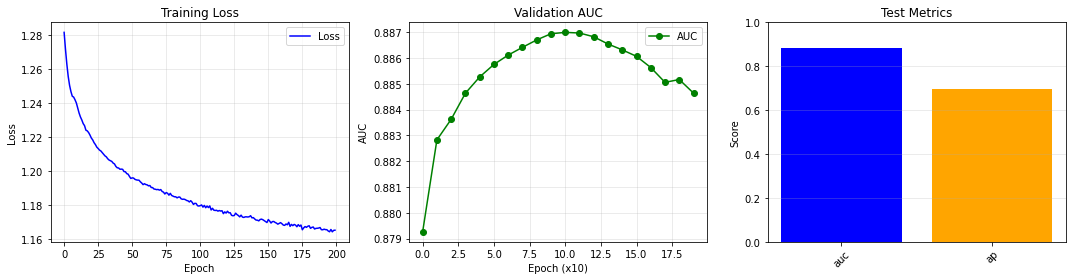

In [7]:
def main_link_prediction():
    configurations = [
        {
            'model_type': 'MGCN',
            'dataset': 'MovieLens1M',
            'num_layers': 2,
            'heads': 1,
            'hidden_dim': 128,
            'embedding_dim': 256,  
            'dropout': 0.4,
            'epochs': 200,
            'optimizer': 'adam',
            'weight_decay': 1e-4,
            'learning_rate': 0.001
        },
    ]

    for config_dict in configurations:
        config = Config(config_dict)
        
        # Set device
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        #print(f"Using device: {device}")

        # Load and prepare data with embedding dimension
        print("\n" + "="*60)
        print("STEP 1: Loading movielens Dataset")
        print("="*60)
        data_path = download_and_extract_movielens()
       
        heterogeneous_data = load_movielens_heterogeneous(data_path, embedding_dim=config.embedding_dim)
        
               
        print("\n" + "="*60)
        print("STEP 2: Converting to Homogeneous Graph")
        print("="*60)
        homogeneous_data = convert_movielens_to_homogeneous(heterogeneous_data)
        homogeneous_data = homogeneous_data.to(device)  # Move to device
        print_dataset_details(homogeneous_data)
        
        print("\n" + "="*60)
        print("STEP 3: Preparing Data for Link Prediction")
        print("="*60)
        homogeneous_data = prepare_link_prediction_data(homogeneous_data)

        print("\n" + "="*60)
        print(f"STEP 4: Training {config.model_type} for LINK PREDICTION")
        print("="*60)

        start_time = time.time()
        val_aucs, losses, best_model, test_metrics = train_link_prediction_model(homogeneous_data, config)
        end_time = time.time()
        elapsed_time = end_time - start_time

        print("\n" + "="*60)
        print("FINAL RESULTS")
        print("="*60)
        print(f"Model: {config.model_type}")
        print(f"Dataset: {config.dataset} (Link Prediction)")
        
        print("\n--- LINK PREDICTION METRICS ---")
        print(f"AUC:       {test_metrics['auc']:.4f}")
        print(f"AP:        {test_metrics['ap']:.4f}")
        
        
        print("\n--- RECOMMENDATION METRICS ---")
        rec_metrics = evaluate_recommendation(best_model, homogeneous_data)
        if rec_metrics:  
            print(f"HR@5:   {rec_metrics['HR@5']:.4f}")
            print(f"HR@10:  {rec_metrics['HR@10']:.4f}")
            print(f"HR@20:  {rec_metrics['HR@20']:.4f}")
            print(f"NDCG@5:  {rec_metrics['NDCG@5']:.4f}")
            print(f"NDCG@10: {rec_metrics['NDCG@10']:.4f}")
            print(f"NDCG@20: {rec_metrics['NDCG@20']:.4f}")
            print(f"MRR:     {rec_metrics['MRR']:.4f}")
        
        print(f"\nTime Taken: {elapsed_time:.2f} seconds")
        print("="*60)

        # Plot results
        plt.figure(figsize=(15, 4))
        
        plt.subplot(1, 3, 1)
        plt.title(f"Training Loss")
        plt.plot(losses, label="Loss", color='blue')
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.subplot(1, 3, 2)
        plt.title("Validation AUC")
        plt.plot(val_aucs, label="AUC", color='green', marker='o')
        plt.xlabel("Epoch (x10)")
        plt.ylabel("AUC")
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.subplot(1, 3, 3)
        metrics_to_plot = ['auc', 'ap']
        values = [test_metrics[m] for m in metrics_to_plot]
        plt.bar(metrics_to_plot, values, color=['blue', 'orange'])
        plt.title("Test Metrics")
        plt.ylim(0, 1)
        plt.ylabel("Score")
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.show()

# ==================== RUN LINK PREDICTION ====================
if __name__ == '__main__':
    main_link_prediction()